In [ ]:
#Importação das bibliotecas
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler    
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


In [ ]:
# Import dos dados
ticker = 'KO'
stock  = yf.Ticker(ticker)
df     = stock.history(start='2020-01-01', end='2026-01-01', interval='1d')
df     = df[['Open', 'High', 'Low', 'Close', 'Volume']]

print(f'✅ Dados descarregados: {df.shape[0]} dias de negociação')
print(f'📅 Período: {df.index[0].date()} → {df.index[-1].date()}')
print(f'\n🔍 Primeiras linhas:')
df.head()

✅ Dados descarregados: 1508 dias de negociação
📅 Período: 2020-01-02 → 2025-12-31

🔍 Primeiras linhas:


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00-05:00,45.705349,45.796232,45.242676,45.432705,11867700
2020-01-03 00:00:00-05:00,44.879160,45.432715,44.689134,45.184853,11354500
2020-01-06 00:00:00-05:00,45.151810,45.366620,45.044403,45.168331,14698300
2020-01-07 00:00:00-05:00,44.986564,45.110492,44.738705,44.821323,9973900
2020-01-08 00:00:00-05:00,44.837855,45.143548,44.738712,44.903950,10676000


In [ ]:
# EDA - Análise Exploratória de Dados
print('=' * 50)
print('📊 INFORMAÇÃO GERAL DO DATASET')
print('=' * 50)
print(f'\n🔷 Shape: {df.shape}')
print(f'🔷 Valores nulos:\n{df.isnull().sum()}')
print(f'\n🔷 Estatísticas descritivas:')
df.describe().round(2)

📊 INFORMAÇÃO GERAL DO DATASET

🔷 Shape: (1508, 5)
🔷 Valores nulos:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

🔷 Estatísticas descritivas:


,Open,High,Low,Close,Volume
count,1508.00,1508.00,1508.00,1508.00,1508.00
mean,54.52,54.91,54.09,54.51,15545591.05
std,8.96,8.98,8.95,8.99,6672106.35
min,32.30,32.41,30.23,31.30,3265500.00
25%,47.57,47.88,47.32,47.62,11632825.00
50%,55.08,55.45,54.78,55.10,14105250.00
75%,59.73,60.09,59.38,59.74,17489000.00
max,72.15,72.41,71.76,72.11,67845700.00


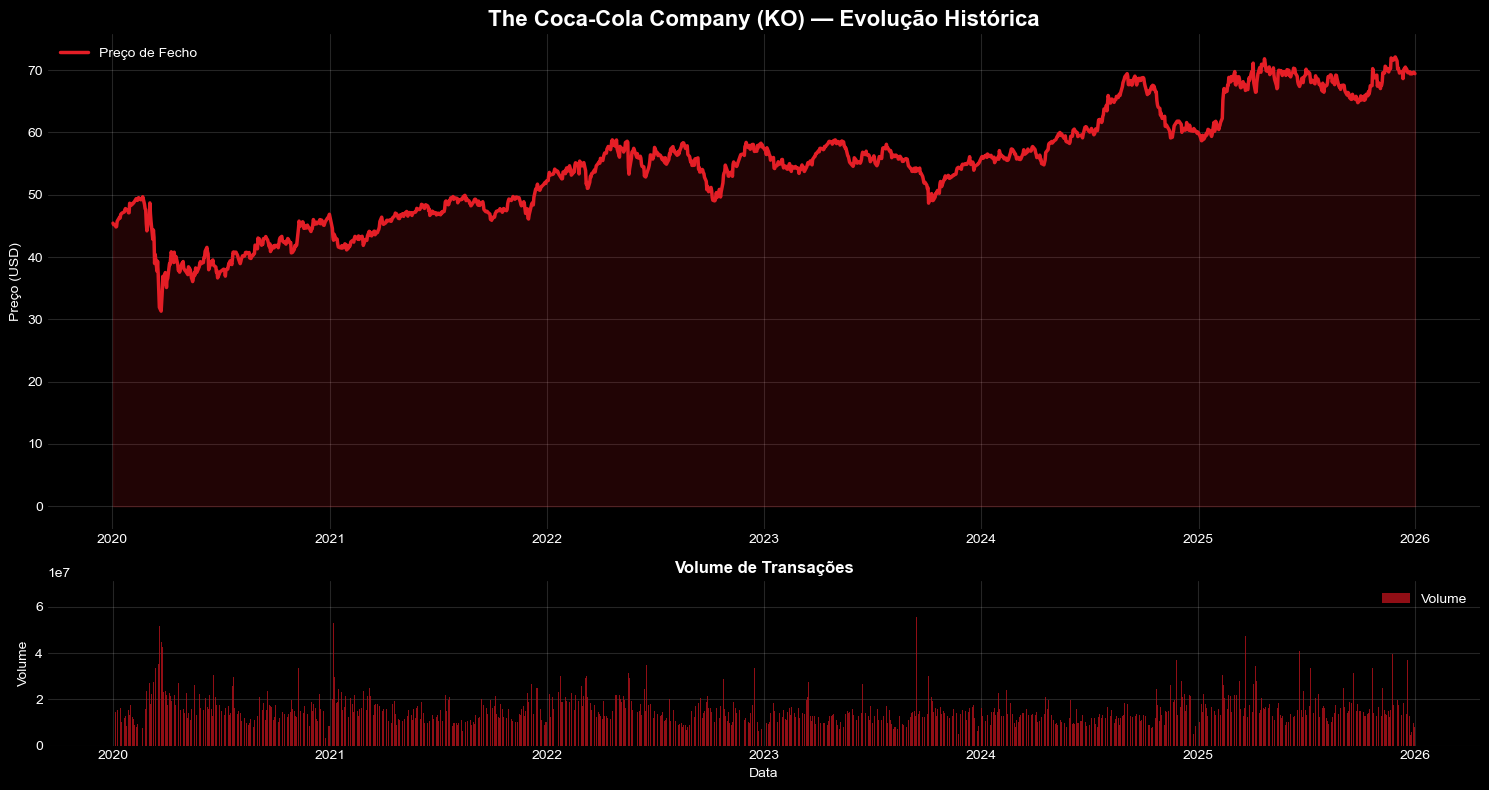

In [220]:
# Gráfico histórico 

plt.style.use('dark_background')

fig, axes = plt.subplots(2, 1, figsize=(15,8), gridspec_kw={'height_ratios':[3,1]})

axes[0].plot(df.index, df['Close'], color='#E41E26', lw=2.5, label='Preço de Fecho')
axes[0].fill_between(df.index, df['Close'], color='#E41E26', alpha=0.15)

axes[0].set_title('The Coca-Cola Company (KO) — Evolução Histórica', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Preço (USD)')
axes[0].grid(alpha=0.15)
axes[0].legend()

axes[1].bar(df.index, df['Volume'], color='#B5121B', alpha=0.8, label='Volume')
axes[1].set_title('Volume de Transações', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Data')
axes[1].grid(alpha=0.15)
axes[1].legend()

plt.tight_layout()
plt.savefig('results/historical_data.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Feature Engineering
df_feat = df.copy()

# 1. Médias Móveis
df_feat['MA_5']  = df_feat['Close'].rolling(window=5).mean()
df_feat['MA_20'] = df_feat['Close'].rolling(window=20).mean()
df_feat['MA_30'] = df_feat['Close'].rolling(window=30).mean()

# 2. Bandas de Bollinger
rolling_21 = df_feat['Close'].rolling(window=21)
df_feat['BB_upper'] = rolling_21.mean() + (rolling_21.std() * 2)
df_feat['BB_lower'] = rolling_21.mean() - (rolling_21.std() * 2)
df_feat['BB_width'] = df_feat['BB_upper'] - df_feat['BB_lower']

# 3. RSI
delta = df_feat['Close'].diff()
gain  = delta.clip(lower=0).rolling(window=14).mean()
loss  = (-delta.clip(upper=0)).rolling(window=14).mean()
rs    = gain / loss
df_feat['RSI'] = 100 - (100 / (1 + rs))

# 4. MACD
ema_12 = df_feat['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df_feat['Close'].ewm(span=26, adjust=False).mean()
df_feat['MACD']        = ema_12 - ema_26
df_feat['MACD_signal'] = df_feat['MACD'].ewm(span=9, adjust=False).mean()
df_feat['MACD_hist']   = df_feat['MACD'] - df_feat['MACD_signal']

# 5. Volatilidade e retorno diário
df_feat['Volatility']   = df_feat['Close'].rolling(window=21).std()
df_feat['Daily_return'] = df_feat['Close'].pct_change()

df_feat.dropna(inplace=True)


print(f'✅ Features criadas! Shape final: {df_feat.shape}')
print(f'\n🔷 Colunas disponíveis:')
for col in df_feat.columns:
    print(f'   • {col}')

✅ Features criadas! Shape final: (1479, 17)

🔷 Colunas disponíveis:
   • Open
   • High
   • Low
   • Close
   • Volume
   • MA_5
   • MA_20
   • MA_30
   • BB_upper
   • BB_lower
   • BB_width
   • RSI
   • MACD
   • MACD_signal
   • MACD_hist
   • Volatility
   • Daily_return


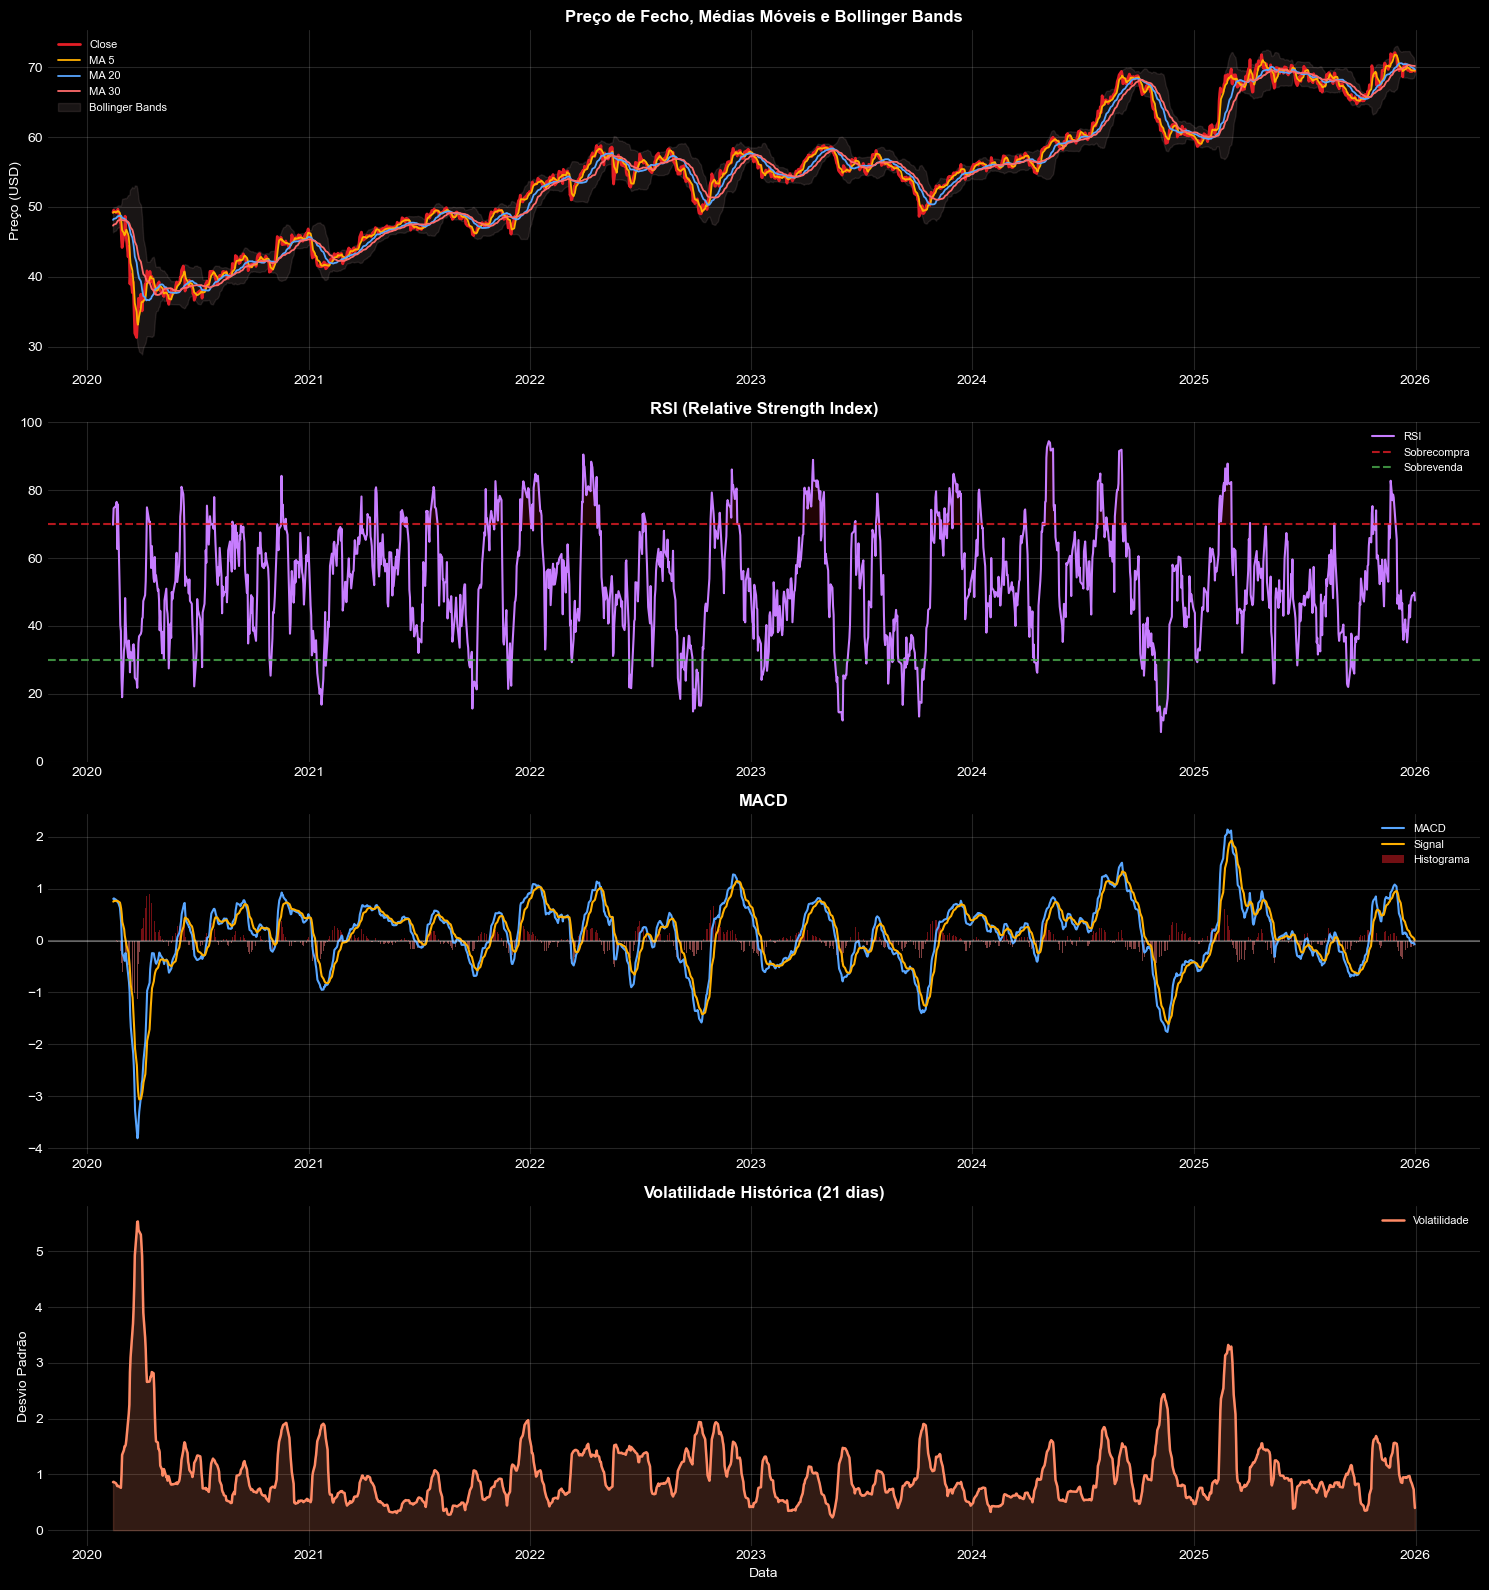

In [221]:
#  Visualizar as features 

fig, axes = plt.subplots(4, 1, figsize=(15,16))

# Preço + Médias + Bollinger
axes[0].plot(df_feat.index, df_feat['Close'], color='#E41E26', lw=2, label='Close')
axes[0].plot(df_feat.index, df_feat['MA_5'], color='#FFB000', lw=1.3, label='MA 5')
axes[0].plot(df_feat.index, df_feat['MA_20'], color='#58A6FF', lw=1.3, label='MA 20')
axes[0].plot(df_feat.index, df_feat['MA_30'], color='#FF6B6B', lw=1.3, label='MA 30')

axes[0].fill_between(df_feat.index, df_feat['BB_upper'], df_feat['BB_lower'], color='#FFD6D6', alpha=0.10, label='Bollinger Bands')

axes[0].set_title('Preço de Fecho, Médias Móveis e Bollinger Bands', fontweight='bold')
axes[0].set_ylabel('Preço (USD)')
axes[0].grid(alpha=0.15)
axes[0].legend(fontsize=8)

# RSI
axes[1].plot(df_feat.index, df_feat['RSI'], color='#C77DFF', lw=1.5, label='RSI')

axes[1].axhline(70, color='#E41E26', linestyle='--', alpha=0.8, label='Sobrecompra')
axes[1].axhline(30, color='#4CAF50', linestyle='--', alpha=0.8, label='Sobrevenda')

axes[1].fill_between(df_feat.index, df_feat['RSI'], 70, where=(df_feat['RSI'] >= 70), color='#E41E26', alpha=0.15)
axes[1].fill_between(df_feat.index, df_feat['RSI'], 30, where=(df_feat['RSI'] <= 30), color='#4CAF50', alpha=0.15)

axes[1].set_title('RSI (Relative Strength Index)', fontweight='bold')
axes[1].set_ylim(0,100)
axes[1].grid(alpha=0.15)
axes[1].legend(fontsize=8)

# MACD
axes[2].plot(df_feat.index, df_feat['MACD'], color='#58A6FF', lw=1.5, label='MACD')
axes[2].plot(df_feat.index, df_feat['MACD_signal'], color='#FFB000', lw=1.5, label='Signal')

axes[2].bar(df_feat.index, df_feat['MACD_hist'],
            color=np.where(df_feat['MACD_hist'] >= 0, '#E41E26', '#FF8080'),
            alpha=0.5, label='Histograma')

axes[2].axhline(0, color='white', alpha=0.3)

axes[2].set_title('MACD', fontweight='bold')
axes[2].grid(alpha=0.15)
axes[2].legend(fontsize=8)

# Volatilidade
axes[3].plot(df_feat.index, df_feat['Volatility'], color='#FF8A65', lw=1.8, label='Volatilidade')
axes[3].fill_between(df_feat.index, df_feat['Volatility'], color='#FF8A65', alpha=0.20)

axes[3].set_title('Volatilidade Histórica (21 dias)', fontweight='bold')
axes[3].set_ylabel('Desvio Padrão')
axes[3].set_xlabel('Data')

axes[3].grid(alpha=0.15)
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/technical_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Pipeline completo: Split → Normalização → Sequências 


SEQUENCE_LENGTH = 30


feature_cols = [
    'Open', 'High', 'Low', 'Volume',
    'MA_5', 'MA_20', 'MA_30', 'Daily_return',
    'Volatility' , 'RSI'
]

target_col = 'Close'

# PASSO 1: Arrays raw 
data_raw   = df_feat[feature_cols].values   # (N, 18)
target_raw = df_feat[[target_col]].values   # (N, 1)
dates      = df_feat.index                  # índice de datas

N = len(data_raw)

# PASSO 2: Split temporal
train_end = int(N * 0.90)
val_end   = int(N * 0.95)

data_train   = data_raw[:train_end]
data_val     = data_raw[train_end:val_end]
data_test    = data_raw[val_end:]

target_train = target_raw[:train_end]
target_val   = target_raw[train_end:val_end]
target_test  = target_raw[val_end:]

# ── PASSO 3: Standardização ─────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()

train_X_scaled = scaler_X.fit_transform(data_train)
train_y_scaled = scaler_y.fit_transform(target_train)

val_X_scaled = scaler_X.transform(data_val)
val_y_scaled = scaler_y.transform(target_val)

test_X_scaled = scaler_X.transform(data_test)
test_y_scaled = scaler_y.transform(target_test)

#  PASSO 4: Criar sequências
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Treino 
X_train, y_train = make_sequences(
    train_X_scaled,
    train_y_scaled,
    SEQUENCE_LENGTH
)

# Validação (mantém contexto do treino) 
val_data_full = np.concatenate([
    train_X_scaled[-SEQUENCE_LENGTH:],
    val_X_scaled
])

val_target_full = np.concatenate([
    train_y_scaled[-SEQUENCE_LENGTH:],
    val_y_scaled
])

X_val, y_val = make_sequences(
    val_data_full,
    val_target_full,
    SEQUENCE_LENGTH
)

# Teste (mantém contexto da validação)
test_data_full = np.concatenate([
    val_X_scaled[-SEQUENCE_LENGTH:],
    test_X_scaled
])

test_target_full = np.concatenate([
    val_y_scaled[-SEQUENCE_LENGTH:],
    test_y_scaled
])

X_test, y_test = make_sequences(
    test_data_full,
    test_target_full,
    SEQUENCE_LENGTH
)

# ── PASSO 5: Índices de datas correspondentes

train_dates = dates[SEQUENCE_LENGTH:train_end]
val_dates   = dates[train_end:val_end]
test_dates  = dates[val_end:N]

print('✅ Pipeline completo!')
print(f'🔷 X_train: {X_train.shape} | datas: {len(train_dates)}')
print(f'🔷 X_val:   {X_val.shape}   | datas: {len(val_dates)}')
print(f'🔷 X_test:  {X_test.shape}  | datas: {len(test_dates)}')
print(f'Target treino: {target_train.min():.5f} → {target_train.max():.5f}')
print(f'Target teste:  {target_test.min():.5f} → {target_test.max():.5f}')

✅ Pipeline completo!
🔷 X_train: (1301, 30, 10) | datas: 1301
🔷 X_val:   (74, 30, 10)   | datas: 74
🔷 X_test:  (74, 30, 10)  | datas: 74
Target treino: 31.30420 → 71.81808
Target teste:  64.76662 → 72.11414


In [ ]:
# Rede Neuronal com arquitetura LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(SEQUENCE_LENGTH, len(feature_cols))
    ),
    Dropout(0.25),

    LSTM(
        64,
        return_sequences=False
    ),
    Dropout(0.25),

    Dense(32, activation='relu'),
    Dropout(0.15),

    Dense(16, activation='relu'),

    Dense(1)

])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='huber',
    metrics=['mae']
)

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 30, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_nvda_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print('✅ Callbacks configurados!')
print('🔷 EarlyStopping     → para se não melhorar em 15 epochs')
print('🔷 ReduceLROnPlateau → reduz learning rate ao fim de 8 epochs sem melhoria')
print('🔷 ModelCheckpoint   → guarda o melhor modelo automaticamente')

✅ Callbacks configurados!
🔷 EarlyStopping     → para se não melhorar em 15 epochs
🔷 ReduceLROnPlateau → reduz learning rate ao fim de 8 epochs sem melhoria
🔷 ModelCheckpoint   → guarda o melhor modelo automaticamente


In [ ]:
# Treino do modelo
print('🚀 A iniciar treino...\n')

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Treino concluído!')
print(f'🔷 Epochs treinadas: {len(history.history["loss"])}')
print(f'🔷 Melhor val_loss:  {min(history.history["val_loss"]):.6f}')

🚀 A iniciar treino...

Epoch 1/100
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2344 - mae: 0.5207
Epoch 1: val_loss improved from None to 0.03376, saving model to best_nvda_model.keras

Epoch 1: finished saving model to best_nvda_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1241 - mae: 0.3534 - val_loss: 0.0338 - val_mae: 0.2347 - learning_rate: 5.0000e-04
Epoch 2/100
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0342 - mae: 0.1913
Epoch 2: val_loss improved from 0.03376 to 0.00983, saving model to best_nvda_model.keras

Epoch 2: finished saving model to best_nvda_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0319 - mae: 0.1809 - val_loss: 0.0098 - val_mae: 0.1102 - learning_rate: 5.0000e-04
Epoch 3/100
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0293 - mae: 0.1757
Epoch 3: val_loss improved from 0.00983 to 0.00504, saving model to best_nvda_model.keras

Epoch 3: finished saving model to best_nvda_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
# Previsões

train_pred = scaler_y.inverse_transform(model.predict(X_train, verbose=0))
val_pred   = scaler_y.inverse_transform(model.predict(X_val, verbose=0))
test_pred  = scaler_y.inverse_transform(model.predict(X_test, verbose=0))

# Valores reais

train_real = scaler_y.inverse_transform(y_train)
val_real   = scaler_y.inverse_transform(y_val)
test_real  = scaler_y.inverse_transform(y_test)

# Métricas

mae  = mean_absolute_error(test_real, test_pred)
rmse = np.sqrt(mean_squared_error(test_real, test_pred))
r2   = r2_score(test_real, test_pred)
mape = np.mean(np.abs((test_real - test_pred) / (np.abs(test_real) + 1e-8))) * 100

# Erro máximo absoluto
max_error = np.max(np.abs(test_real - test_pred))

next_day_prediction = float(test_pred[-1])

last_prediction = float(test_pred[-1])
last_date = test_dates[-1]

print('✅ Previsões geradas!')

print('\n📊 MÉTRICAS NO CONJUNTO DE TESTE')
print('='*50)
print(f'MAE        : ${mae:.2f}')
print(f'RMSE       : ${rmse:.2f}')
print(f'Erro Máx.  : ${max_error:.2f}')
print(f'R²         : {r2:.4f}')
print(f'MAPE       : {mape:.2f}%')
print('='*50)

print('\n🎯 NEXT-DAY FORECAST')
print('='*50)
print(f'Date of latest available data : {last_date.strftime("%Y-%m-%d")}')
print(f'Predicted next-day close      : ${next_day_prediction:.2f}')
print('='*50)

✅ Previsões geradas!

📊 MÉTRICAS NO CONJUNTO DE TESTE
MAE        : $0.51
RMSE       : $0.70
Erro Máx.  : $2.84
R²         : 0.8892
MAPE       : 0.74%

🎯 NEXT-DAY FORECAST
Date of latest available data : 2025-12-31
Predicted next-day close      : $69.29


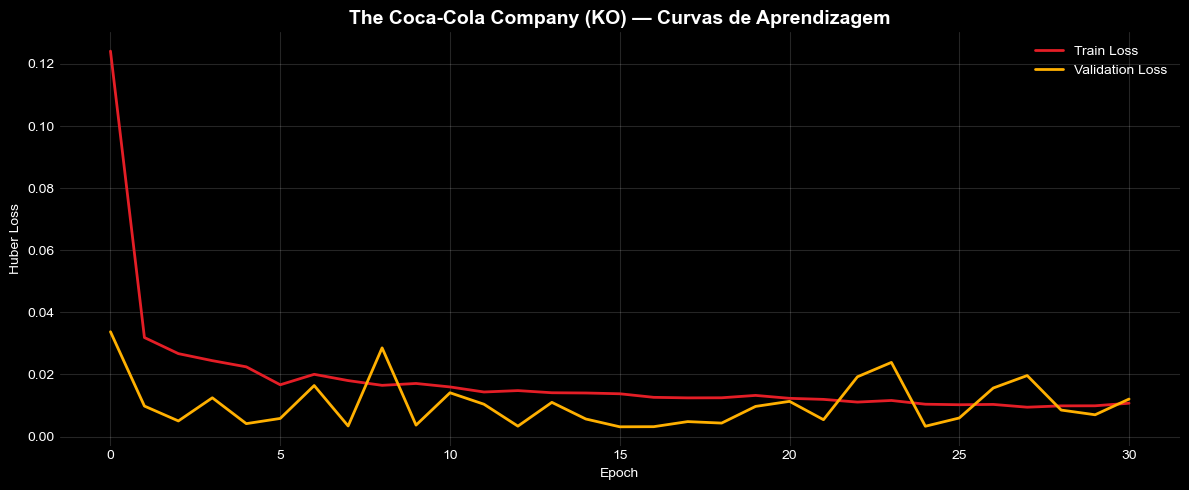

In [222]:
# Curvas de aprendizagem

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(history.history['loss'], color='#E41E26', lw=2, label='Train Loss')
ax.plot(history.history['val_loss'], color='#FFB000', lw=2, label='Validation Loss')

ax.set_title('The Coca-Cola Company (KO) — Curvas de Aprendizagem', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')

ax.grid(alpha=0.15)
ax.legend()

plt.tight_layout()
plt.savefig('results/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

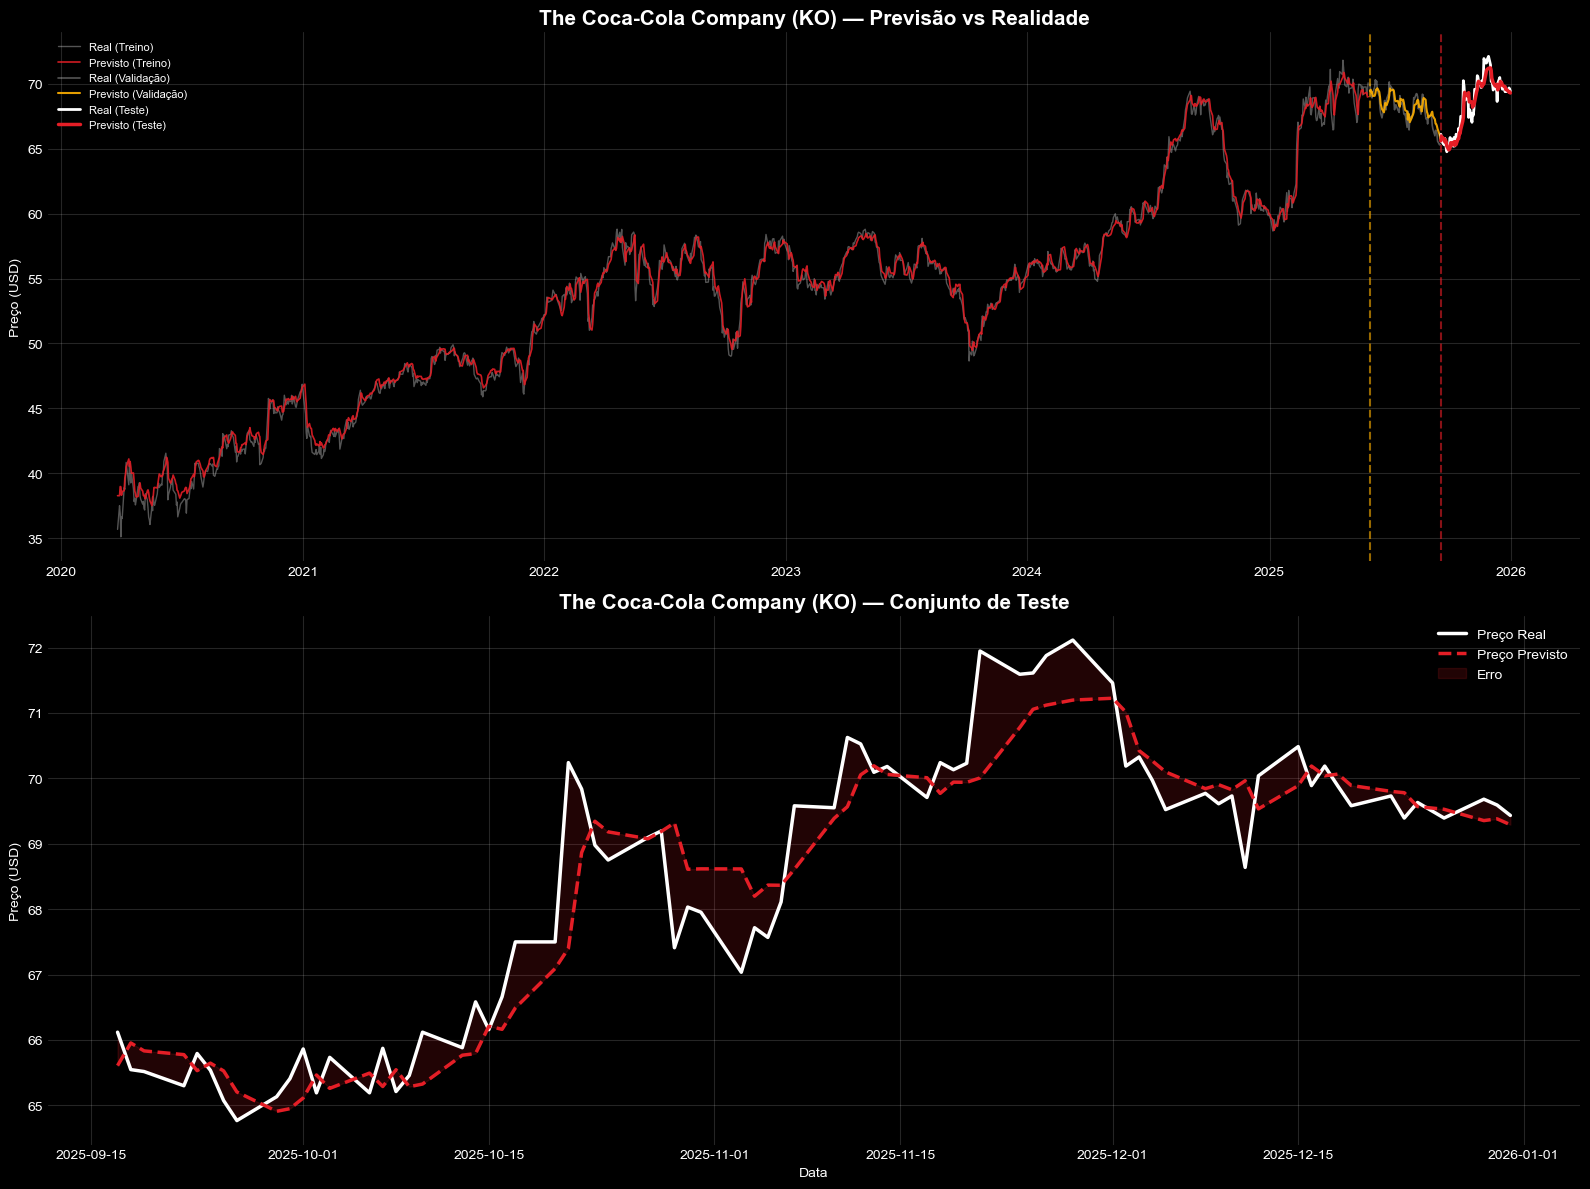

In [223]:
# Gráficos de previsão

fig, axes = plt.subplots(2, 1, figsize=(16,12))

# Visão completa
axes[0].plot(train_dates, train_real, color='lightgray', lw=1, alpha=0.4, label='Real (Treino)')
axes[0].plot(train_dates, train_pred, color='#E41E26', lw=1.2, alpha=0.9, label='Previsto (Treino)')

axes[0].plot(val_dates, val_real, color='lightgray', lw=1.2, alpha=0.4, label='Real (Validação)')
axes[0].plot(val_dates, val_pred, color='#FFB000', lw=1.5, alpha=0.9, label='Previsto (Validação)')

axes[0].plot(test_dates, test_real, color='white', lw=2, label='Real (Teste)')
axes[0].plot(test_dates, test_pred, color='#E41E26', lw=2.5, label='Previsto (Teste)')

axes[0].axvline(x=val_dates[0], color='#FFB000', linestyle='--', alpha=0.6)
axes[0].axvline(x=test_dates[0], color='#E41E26', linestyle='--', alpha=0.6)

axes[0].set_title('The Coca-Cola Company (KO) — Previsão vs Realidade', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Preço (USD)')
axes[0].grid(alpha=0.15)
axes[0].legend(fontsize=8)

# Foco no teste
axes[1].plot(test_dates, test_real, color='white', lw=2.5, label='Preço Real')
axes[1].plot(test_dates, test_pred, color='#E41E26', lw=2.5, linestyle='--', label='Preço Previsto')

axes[1].fill_between(test_dates, test_real.flatten(), test_pred.flatten(), color='#E41E26', alpha=0.15, label='Erro')

axes[1].set_title('The Coca-Cola Company (KO) — Conjunto de Teste', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Preço (USD)')
axes[1].set_xlabel('Data')

axes[1].grid(alpha=0.15)
axes[1].legend()

plt.tight_layout()
plt.savefig('results/forecast_results.png', dpi=300, bbox_inches='tight')
plt.show()